In [ ]:
import time
import os
import pandas as pd
from sklearn.model_selection import train_test_split
from torchvision import datasets, transforms
from torch.utils.data import DataLoader
from sklearn.metrics import classification_report
from sklearn.metrics import confusion_matrix

import numpy as np
import cv2

import torch
from torch import nn
import torch.nn.functional as F
from torch.utils.data import DataLoader, Dataset

import torchvision
from torchvision import transforms
import torchvision.models as models

import torch.optim as optim
from torch.optim.lr_scheduler import StepLR

from tqdm.notebook import tqdm

from sklearn.metrics import accuracy_score
import PIL
import matplotlib.pyplot as plt
import seaborn as sns

import time
from collections import OrderedDict

import platform
import psutil

import random
import glob
from tqdm import tqdm

from PIL import Image
from torchvision import transforms
from PIL import ImageOps

from tabulate import tabulate

In [ ]:
seed = 1
torch.manual_seed(seed)
torch.cuda.manual_seed(seed)
np.random.seed(seed)
random.seed(seed)

In [ ]:
from google.colab import files
files.upload()

Saving kaggle.json to kaggle.json


{'kaggle.json': b'{"username":"ratul100","key":"3671bd913dd442c010fecf06dd130d5a"}'}

In [ ]:
!mkdir -p ~/.kaggle
!mv kaggle.json ~/.kaggle/
!chmod 600 ~/.kaggle/kaggle.json

In [ ]:
!kaggle datasets download -d rm1000/grape-disease-dataset-original

Dataset URL: https://www.kaggle.com/datasets/rm1000/grape-disease-dataset-original
License(s): CC0-1.0
 78% 118M/151M [00:00<00:00, 1.23GB/s]
100% 151M/151M [00:00<00:00, 1.12GB/s]


In [ ]:
!unzip -q grape-disease-dataset-original.zip -d dataset

In [ ]:
!ls dataset

'Original Data'


In [ ]:
!ls /content/dataset/Original\ Data

test  train


Classes found: ['ESCA', 'Healthy', 'Leaf Blight', 'Black Rot']


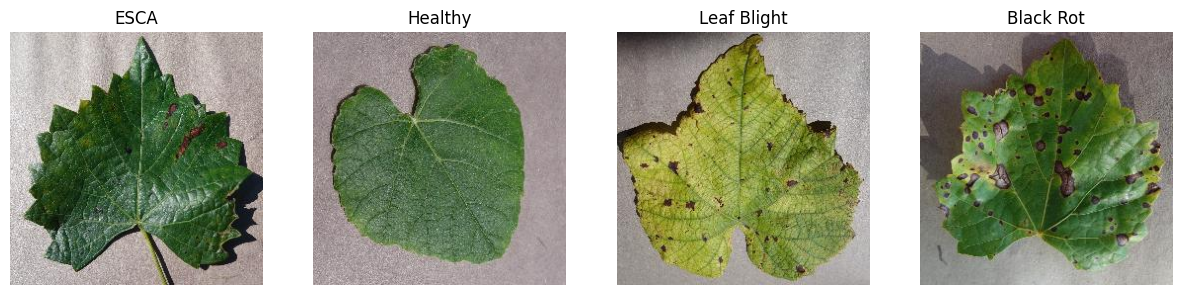

In [ ]:

data_dir = '/content/dataset/Original Data/train'
classes = os.listdir(data_dir)
print("Classes found:", classes)

plt.figure(figsize=(15, 5))
for i, cls in enumerate(classes):
    img_path = os.path.join(data_dir, cls, os.listdir(os.path.join(data_dir, cls))[0])
    img = cv2.imread(img_path)
    img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    plt.subplot(1, len(classes), i+1)
    plt.imshow(img_rgb)
    plt.title(cls)
    plt.axis('off')
plt.show()

In [ ]:
train_dir = '/content/dataset/Original Data/train'
test_dir = '/content/dataset/Original Data/test'

def count_images(directory):
    total_images = 0
    class_counts = {}

    # Get class folders
    classes = os.listdir(directory)
    for cls in classes:
        class_path = os.path.join(directory, cls)
        if os.path.isdir(class_path):  # Ensure it’s a directory
            num_images = len([f for f in os.listdir(class_path) if f.endswith(('.JPG', '.JPEG', '.PNG'))])
            class_counts[cls] = num_images
            total_images += num_images

    return total_images, class_counts

train_total, train_class_counts = count_images(train_dir)
test_total, test_class_counts = count_images(test_dir)

print("Training Dataset:")
print(f"Total images: {train_total}")
print("Images per class:", train_class_counts)
print("\nTest Dataset:")
print(f"Total images: {test_total}")
print("Images per class:", test_class_counts)

Training Dataset:
Total images: 7222
Images per class: {'ESCA': 1920, 'Healthy': 1692, 'Leaf Blight': 1722, 'Black Rot': 1888}

Test Dataset:
Total images: 1805
Images per class: {'ESCA': 480, 'Healthy': 423, 'Leaf Blight': 430, 'Black Rot': 472}


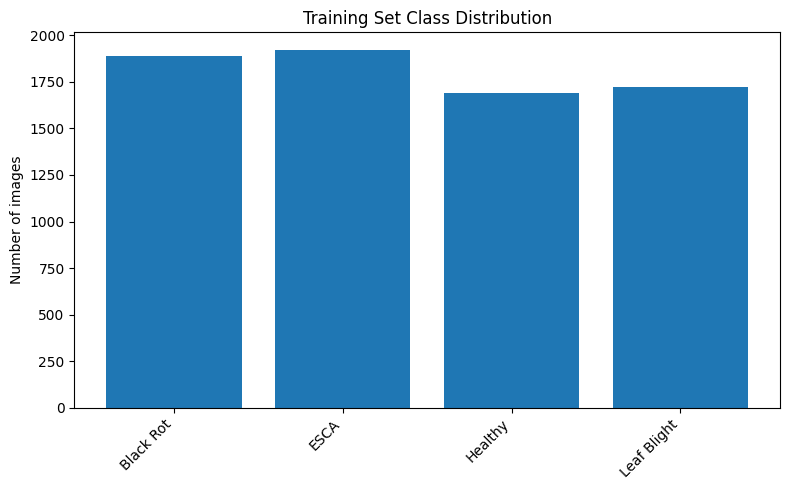

In [ ]:
import os
import matplotlib.pyplot as plt


train_dir = '/content/dataset/Original Data/train'


classes = sorted([d for d in os.listdir(train_dir)
                  if os.path.isdir(os.path.join(train_dir, d))])
counts = []
for cls in classes:
    cls_dir = os.path.join(train_dir, cls)

    imgs = [f for f in os.listdir(cls_dir)
            if f.lower().endswith(('.png', '.jpg', '.jpeg', '.bmp', '.gif'))]
    counts.append(len(imgs))


plt.figure(figsize=(8, 5))
plt.bar(classes, counts)
plt.title('Training Set Class Distribution')
plt.ylabel('Number of images')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

In [ ]:
import os
import numpy as np
from sklearn.model_selection import StratifiedShuffleSplit

import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import datasets, transforms, models
from torch.utils.data import DataLoader, Subset
import matplotlib.pyplot as plt

# ─── Paths ────────────────────────────────────────────────────────────────────────
train_dir = '/content/dataset/Original Data/train'
test_dir  = '/content/dataset/Original Data/test'

# ─── Transforms ──────────────────────────────────────────────────────────────────
train_transforms = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(15),
    transforms.ToTensor(),
    transforms.Normalize([0.485,0.456,0.406], [0.229,0.224,0.225]),
])

val_test_transforms = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize([0.485,0.456,0.406], [0.229,0.224,0.225]),
])

# ─── Stratified Split ────────────────────────────────────────────────────────────
full_dataset = datasets.ImageFolder(train_dir)
targets = full_dataset.targets
sss = StratifiedShuffleSplit(n_splits=1, test_size=0.10, random_state=42)
train_idx, val_idx = next(sss.split(np.zeros(len(targets)), targets))

train_dataset = Subset(
    datasets.ImageFolder(train_dir, transform=train_transforms),
    train_idx
)
val_dataset = Subset(
    datasets.ImageFolder(train_dir, transform=val_test_transforms),
    val_idx
)
test_dataset = datasets.ImageFolder(test_dir, transform=val_test_transforms)

# ─── DataLoaders ────────────────────────────────────────────────────────────────
batch_size  = 8
num_workers = 2
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True,  num_workers=num_workers)
val_loader   = DataLoader(val_dataset,   batch_size=batch_size, shuffle=False, num_workers=num_workers)
test_loader  = DataLoader(test_dataset,  batch_size=batch_size, shuffle=False, num_workers=num_workers)

print(f"Train samples: {len(train_dataset)}")
print(f"Val   samples: {len(val_dataset)}")
print(f"Test  samples: {len(test_dataset)}")
print("Class distribution in train split:", np.bincount(np.array(full_dataset.targets)[train_idx]))
print("Class distribution in val split:  ", np.bincount(np.array(full_dataset.targets)[val_idx]))

Train samples: 6499
Val   samples: 723
Test  samples: 1805
Class distribution in train split: [1699 1728 1523 1549]
Class distribution in val split:   [189 192 169 173]


/usr/local/lib/python3.11/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=MobileNet_V3_Large_Weights.IMAGENET1K_V1`. You can also use `weights=MobileNet_V3_Large_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)
Downloading: "https://download.pytorch.org/models/mobilenet_v3_large-8738ca79.pth" to /root/.cache/torch/hub/checkpoints/mobilenet_v3_large-8738ca79.pth
100%|██████████| 21.1M/21.1M [00:00<00:00, 94.1MB/s]


Epoch 01/15 | Train loss=0.6182, acc=0.8574 | Val   loss=0.2116, acc=0.9571
Epoch 02/15 | Train loss=0.2781, acc=0.9378 | Val   loss=0.1267, acc=0.9654
Epoch 03/15 | Train loss=0.2110, acc=0.9420 | Val   loss=0.0931, acc=0.9751
Epoch 04/15 | Train loss=0.1828, acc=0.9463 | Val   loss=0.0812, acc=0.9751
Epoch 05/15 | Train loss=0.1686, acc=0.9451 | Val   loss=0.0754, acc=0.9737
Epoch 06/15 | Train loss=0.1473, acc=0.9580 | Val   loss=0.0613, acc=0.9793
Epoch 07/15 | Train loss=0.1513, acc=0.9503 | Val   loss=0.0602, acc=0.9779
Epoch 08/15 | Train loss=0.1321, acc=0.9577 | Val   loss=0.0600, acc=0.9779
Epoch 09/15 | Train loss=0.1301, acc=0.9586 | Val   loss=0.0533, acc=0.9765
Epoch 10/15 | Train loss=0.1240, acc=0.9577 | Val   loss=0.0486, acc=0.9834
Epoch 11/15 | Train loss=0.1232, acc=0.9591 | Val   loss=0.0474, acc=0.9834
Epoch 12/15 | Train loss=0.1226, acc=0.9560 | Val   loss=0.0460, acc=0.9834
Epoch 13/15 | Train loss=0.1143, acc=0.9618 | Val   loss=0.0422, acc=0.9834
Epoch 14/15 

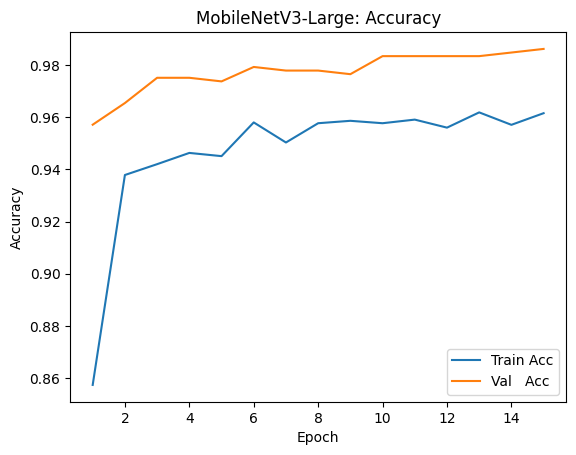

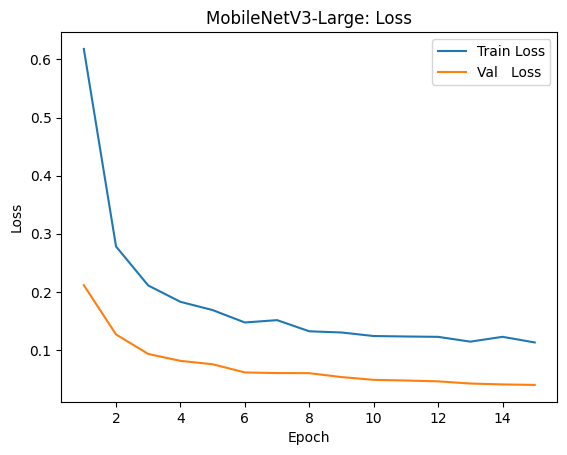

In [ ]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
num_classes = len(full_dataset.classes)
model = models.mobilenet_v3_large(pretrained=True)

# Freeze feature extractor
for param in model.features.parameters():
    param.requires_grad = False

# Replace final classifier layer
# classifier structure: [0]=Linear, [1]=Hardswish, [2]=Dropout, [3]=Linear
in_features = model.classifier[3].in_features
model.classifier[3] = nn.Linear(in_features, num_classes)
model = model.to(device)

# ─── Loss & Optimizer ────────────────────────────────────────────────────────────
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.classifier[3].parameters(), lr=1e-4)

# ─── Training & Validation Functions ─────────────────────────────────────────────
def train_one_epoch(loader):
    model.train()
    running_loss, running_corrects = 0.0, 0
    for imgs, labels in loader:
        imgs, labels = imgs.to(device), labels.to(device)
        optimizer.zero_grad()
        outputs = model(imgs)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        running_loss    += loss.item() * imgs.size(0)
        running_corrects += (outputs.argmax(1) == labels).sum().item()
    return running_loss / len(loader.dataset), running_corrects / len(loader.dataset)

def validate(loader):
    model.eval()
    val_loss, val_corrects = 0.0, 0
    with torch.no_grad():
        for imgs, labels in loader:
            imgs, labels = imgs.to(device), labels.to(device)
            outputs = model(imgs)
            loss = criterion(outputs, labels)
            val_loss     += loss.item() * imgs.size(0)
            val_corrects += (outputs.argmax(1) == labels).sum().item()
    return val_loss / len(loader.dataset), val_corrects / len(loader.dataset)

# ─── Training Loop ────────────────────────────────────────────────────────────────
train_accs, val_accs = [], []
train_losses, val_losses = [], []
max_epochs = 15

for epoch in range(1, max_epochs + 1):
    train_loss, train_acc = train_one_epoch(train_loader)
    val_loss,   val_acc   = validate(val_loader)
    train_losses.append(train_loss)
    val_losses.append(val_loss)
    train_accs.append(train_acc)
    val_accs.append(val_acc)
    print(f"Epoch {epoch:02d}/{max_epochs} | "
          f"Train loss={train_loss:.4f}, acc={train_acc:.4f} | "
          f"Val   loss={val_loss:.4f}, acc={val_acc:.4f}")

# Save model
torch.save(model.state_dict(), 'mobilenetv3_large_best.pth')

# ─── Plot Accuracy & Loss ────────────────────────────────────────────────────────
epochs = range(1, max_epochs + 1)

plt.figure()
plt.plot(epochs, train_accs, label='Train Acc')
plt.plot(epochs, val_accs,   label='Val   Acc')
plt.xlabel('Epoch'); plt.ylabel('Accuracy')
plt.title('MobileNetV3-Large: Accuracy')
plt.legend(); plt.show()

plt.figure()
plt.plot(epochs, train_losses, label='Train Loss')
plt.plot(epochs, val_losses,   label='Val   Loss')
plt.xlabel('Epoch'); plt.ylabel('Loss')
plt.title('MobileNetV3-Large: Loss')
plt.legend(); plt.show()

In [ ]:
from sklearn.metrics import confusion_matrix, classification_report
import torch
import numpy as np

model.load_state_dict(torch.load('mobilenetv3_large_best.pth', map_location=device))
model.eval()
all_preds = []
all_labels = []

with torch.no_grad():
    for imgs, labels in test_loader:
        imgs = imgs.to(device)
        outputs = model(imgs)
        _, preds = torch.max(outputs, 1)
        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.numpy())

all_preds  = np.array(all_preds)
all_labels = np.array(all_labels)


test_acc = (all_preds == all_labels).mean()
print(f"Test Accuracy: {test_acc:.4f}")


cm = confusion_matrix(all_labels, all_preds)
print("Confusion Matrix:\n", cm)

print("\nClassification Report:")
print(classification_report(all_labels, all_preds, target_names=full_dataset.classes))

Test Accuracy: 0.9839
Confusion Matrix:
 [[453  18   1   0]
 [  9 471   0   0]
 [  0   0 423   0]
 [  1   0   0 429]]

Classification Report:
              precision    recall  f1-score   support

   Black Rot       0.98      0.96      0.97       472
        ESCA       0.96      0.98      0.97       480
     Healthy       1.00      1.00      1.00       423
 Leaf Blight       1.00      1.00      1.00       430

    accuracy                           0.98      1805
   macro avg       0.98      0.98      0.98      1805
weighted avg       0.98      0.98      0.98      1805



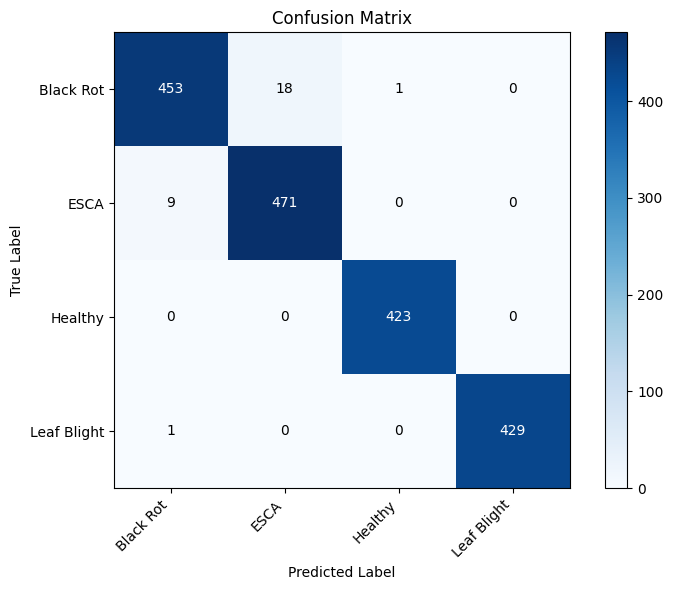

In [ ]:
import matplotlib.pyplot as plt
import numpy as np



fig, ax = plt.subplots(figsize=(8, 6))
im = ax.imshow(cm, interpolation='nearest', cmap='Blues')
fig.colorbar(im, ax=ax)


ax.set_xticks(np.arange(len(classes)))
ax.set_yticks(np.arange(len(classes)))
ax.set_xticklabels(classes, rotation=45, ha='right')
ax.set_yticklabels(classes)


for i in range(len(classes)):
    for j in range(len(classes)):
        ax.text(j, i, cm[i, j],
                ha='center', va='center',
                color='white' if cm[i, j] > cm.max()/2 else 'black')

ax.set_ylabel('True Label')
ax.set_xlabel('Predicted Label')
ax.set_title('Confusion Matrix')
plt.tight_layout()
plt.show()

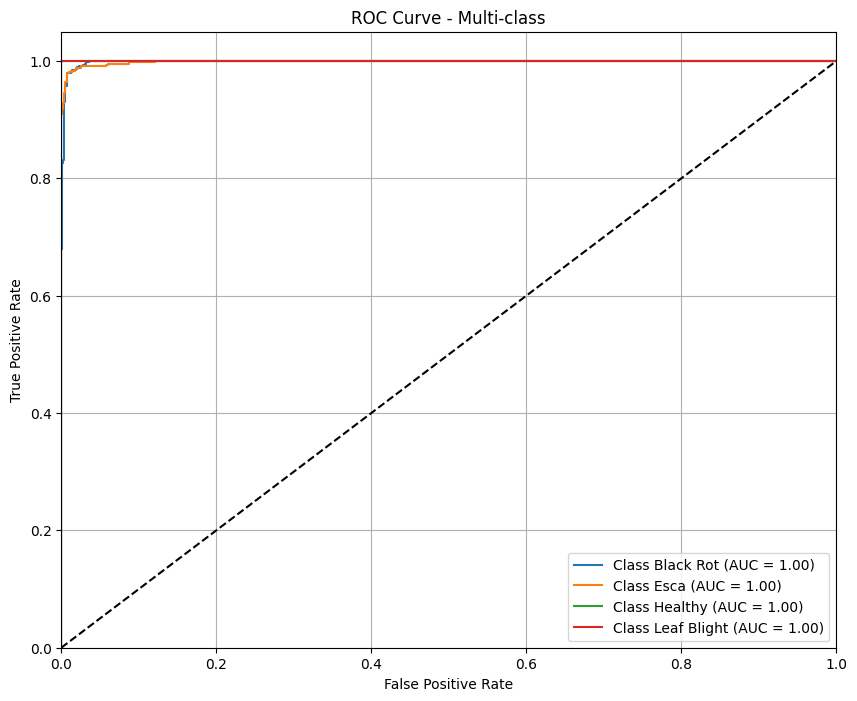

In [ ]:
from sklearn.metrics import roc_curve, auc
from sklearn.preprocessing import label_binarize
import matplotlib.pyplot as plt
import numpy as np
import torch
import torch.nn.functional as F

def plot_roc_curve(model, dataloader, class_names, device):
    model.eval()
    all_labels = []
    all_probs = []

    with torch.no_grad():
        for inputs, labels in dataloader:
            inputs = inputs.to(device)
            labels = labels.to(device)

            outputs = model(inputs)
            probs = F.softmax(outputs, dim=1)

            all_labels.extend(labels.cpu().numpy())
            all_probs.extend(probs.cpu().numpy())

    # Binarize labels for multi-class ROC
    all_labels = label_binarize(all_labels, classes=list(range(len(class_names))))
    all_probs = np.array(all_probs)

    fpr = dict()
    tpr = dict()
    roc_auc = dict()

    for i in range(len(class_names)):
        fpr[i], tpr[i], _ = roc_curve(all_labels[:, i], all_probs[:, i])
        roc_auc[i] = auc(fpr[i], tpr[i])

    # Plot all ROC curves
    plt.figure(figsize=(10, 8))
    for i in range(len(class_names)):
        plt.plot(fpr[i], tpr[i], label=f'Class {class_names[i]} (AUC = {roc_auc[i]:.2f})')

    plt.plot([0, 1], [0, 1], 'k--')  # Diagonal line
    plt.xlim([0.0, 1.0])
    plt.ylim([0.0, 1.05])
    plt.xlabel('False Positive Rate')
    plt.ylabel('True Positive Rate')
    plt.title('ROC Curve - Multi-class')
    plt.legend(loc='lower right')
    plt.grid(True)
    plt.show()

plot_roc_curve(model, test_loader, class_names=['Black Rot', 'Esca', 'Healthy', 'Leaf Blight'], device=device)
